# TS4: Primeras nociones de estimación espectral

En esta tarea continuaremos con el capítulo 14 de *Holton, DSP Principles and Applications.*

Comenzaremos con la generación de la siguiente señal:

$$
x(n) = a_0 \cdot \sin(\Omega_1 \cdot n) + n_a(n)
$$

donde:

$$
a_0 = \sqrt{2}
$$

$$
\Omega_1 = \Omega_0 + f_r \cdot \frac{2\pi}{N}
$$

$$
\Omega_0 = \frac{\pi}{2}
$$

La variable aleatoria $f_r$ está definida por la siguiente distribución:

$$
f_r \sim U(-2, 2)
$$

y el ruido aditivo:

$$
n_a \sim \mathcal{N}(0, \sigma^2)
$$

---

## Estimadores

Se desea diseñar los siguientes estimadores de amplitud $\hat{a}_1^i$ y frecuencia $\hat{\Omega}_1^i$:

### Estimador de amplitud

$$
\hat{a}_1^i = \left| X_w^i(\Omega_0) \right| = \left| \mathcal{F}\{ x(n)\, w_i(n) \} \right|
$$

### Estimador de frecuencia

$$
\hat{\Omega}_1^i = \arg\max_{\Omega} \left| X_w^i(\Omega) \right|
$$

para cada una de las siguientes ventanas:

- rectangular (sin ventana)  
- flattop  
- blackmanharris  
- otra a elección de `scipy.signal.windows` (se eligió **Hamming**)

---

## Consignas de experimentación

- Considere **200 realizaciones** (muestras de $f_r$) de **1000 muestras** cada una.  
- Parametrice para **SNR = 3 dB** y **SNR = 10 dB**.  
- *Ayuda:* calibre $a_1$ para que la potencia de la senoidal sea **1 W**.

---

## Cálculo del sesgo y la varianza

Para el estimador de amplitud:

$$
\hat{a}_0 = |X_w(\Omega_0)|
$$

Sesgo:

$$
s_a = \mathbb{E}\{\hat{a}_0\} - a_0
$$

Varianza:

$$
v_a = \mathrm{var}\{\hat{a}_0\} = \mathbb{E}\left[(\hat{a}_0 - \mathbb{E}\{\hat{a}_0\})^2\right]
$$

Aproximación mediante medias muestrales (con $M$ realizaciones):

$$
\mathbb{E}\{\hat{a}_0\} \approx \mu_{\hat{a}} = \frac{1}{M}\sum_{j=0}^{M-1} \hat{a}_j
$$

$$
s_a = \mu_{\hat{a}} - a_0
$$

$$
v_a = \frac{1}{M}\sum_{j=0}^{M-1} (\hat{a}_j - \mu_{\hat{a}})^2
$$

---

## Tablas solicitadas

### Estimación de Amplitud

| Ventana        | $s_a$ (10 dB) | $v_a$ (10 dB) | $s_a$ (3 dB) | $v_a$ (3 dB) |
|----------------|----------------:|----------------:|----------------:|----------------:|
| Rectangular    | -0.8779 | 0.20435 | -0.8774 | 0.20497 |
| Flat-top       | -0.1172 | 0.02342 | -0.1095 | 0.02502 |
| Blackman-Harris| -0.4740 | 0.14025 | -0.4686 | 0.13814 |
| Hamming        | -0.7324 | 0.24944 | -0.7247 | 0.24277 |

---

### Estimación de Frecuencia [rad/muestra]

| Ventana        | $s_f$ (10 dB) | $v_f$ (10 dB) | $s_f$ (3 dB) | $v_f$ (3 dB) |
|----------------|----------------:|----------------:|----------------:|----------------:|
| Rectangular    | -1.05e-04 | 3.44e-06 | -1.05e-04 | 3.44e-06 |
| Flat-top       | -1.99e-04 | 4.61e-06 | -2.31e-04 | 7.46e-06 |
| Blackman-Harris| -1.05e-04 | 3.44e-06 | -1.37e-04 | 3.44e-06 |
| Hamming        | -1.05e-04 | 3.44e-06 | -1.37e-04 | 3.44e-06 |

---

### Estimación de Frecuencia con zero padding ($N_{zp} = 10N$) [rad/muestra]

| Ventana        | $s_f$ (10 dB) | $v_f$ (10 dB) | $s_f$ (3 dB) | $v_f$ (3 dB) |
|----------------|----------------:|----------------:|----------------:|----------------:|
| Rectangular    | 2.04e-05 | 3.32e-08 | 1.10e-05 | 3.83e-08 |
| Flat-top       | 9.58e-05 | 6.03e-06 | -6.13e-05 | 8.55e-06 |
| Blackman-Harris| 2.98e-05 | 3.45e-08 | 7.85e-06 | 7.22e-08 |
| Hamming        | 2.04e-05 | 3.29e-08 | 2.36e-05 | 4.22e-08 |

## Introducción

El objetivo de esta tarea es estudiar estimadores de **amplitud** y de **frecuencia** de una senoidal contaminada con ruido, y comparar su desempeño según la **ventana** aplicada antes de calcular la DFT.

El análisis se realiza utilizando:

- $200$ realizaciones,
- cada una con una **desintonía aleatoria** distinta,
- y se evalúan el **sesgo** y la **varianza** de cada estimador.

Se toma $f_s = 2\pi$, de modo que el eje de frecuencias queda directamente en $\Omega$ [rad/muestra] y la resolución espectral es $\Delta f = 2\pi/N$. Así, $\Omega_0 = \pi/2$ cae exactamente en el bin $N/4$ y $f_r$ representa la desintonía medida en bins.

El propósito final es observar cómo la elección de la ventana afecta la calidad de los estimadores en presencia de ruido.

## Ruido y SNR

Para cada valor de SNR (10 dB y 3 dB) se calcula la potencia de ruido necesaria mediante:

$$
P_n = \frac{P_s}{10^{\mathrm{SNR}/10}}
$$

donde:

$$
P_s = \frac{a_0^2}{2} = 1 \, \text{W}
$$

El desvío estándar del ruido gaussiano es:

$$
\sigma_n = \sqrt{P_n}
$$

Con $\mathrm{SNR} = 10\,\text{dB}$, el ruido es diez veces más débil que la señal en potencia.  
Con $\mathrm{SNR} = 3\,\text{dB}$, el ruido es solo la mitad de la potencia de la señal, por lo que la dispersión de los estimadores debería aumentar al disminuir el SNR.

---

## Estimador de amplitud

El estimador se define como:

$$
\text{estimador}_a = 2 \cdot \left| S_{\text{vent}}[:, N/4] \right|
$$

Es decir, se toma el módulo de la DFT en el bin de $\Omega_0$ ($N/4$) y se multiplica por 2 para recuperar la amplitud completa de la senoidal real (cuya energía se reparte entre frecuencia positiva y negativa). Cada ventana se divide por su media para que su ganancia coherente sea 1 y así comparar todas en la misma escala.

El sesgo se calcula como:

$$
s_a = \mu_{\hat{a}} - a_0
$$

y la varianza corresponde a la dispersión de los 200 valores obtenidos.

La ventana **flattop** debería producir el menor sesgo, ya que su lóbulo principal es plano en la cima: aun con desintonía, el valor del pico cambia muy poco, que es precisamente el objetivo de su diseño.

---

## Estimador de frecuencia

Se toma el bin donde $|X_w(\Omega)|$ es máximo y se multiplica por $\Delta f$ para expresarlo en rad/muestra. Como $\Omega_1$ cambia en cada realización, el sesgo y la varianza se calculan sobre el error $\hat{\Omega}_1 - \Omega_1$.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import windows

np.random.seed(0) # semilla para que los resultados sean reproducibles

# Parámetros
N = 1000 # cantidad de muestras
R = 200 # cantidad de realizaciones
fs = 2*np.pi # frecuencia de muestreo. 
#La frecuencia de muestreo es 2 pi --> el eje de frecuencia queda directamente en Ω [rad/muestra]
df = fs / N # resolución espectral = 2pi/N
Ts = 1 / fs
a0 = np.sqrt(2) # amplitud --> potencia de la senoidal = a0^2/2 = 1 W
omega0 = np.pi/2 # cae justo en el bin N/4
fr = np.random.uniform(-2,2, size = R) # desintonía en bins

# Eje de muestras
n = np.arange(N)
n = n.reshape(1, N)

t = np.arange(N) / fs
tt = np.tile(t, (R,1))   # matriz 200x1000

omega1 = omega0 + fr * df
omega1 = omega1.reshape(R, 1)

ff = np.arange(N) * df # Vector en frecuencia al escalar las muestras por la resolucion espectral
f = omega1*n # matriz 200x1000: cada fila es Ω1·n de una realización
ff = ff.reshape(N, 1)

# Ventanas normalizadas (divididas por su media) para calibrar la amplitud
win_R = windows.boxcar(N);         win_R = win_R / win_R.mean()
win_F = windows.flattop(N);        win_F = win_F / win_F.mean()
win_B = windows.blackmanharris(N); win_B = win_B / win_B.mean()
win_H = windows.hamming(N);        win_H = win_H / win_H.mean()

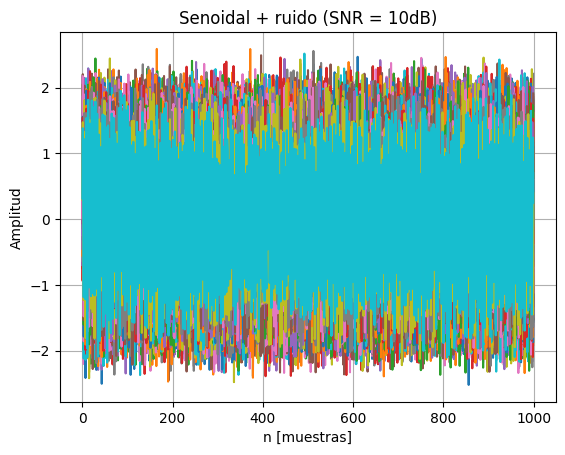

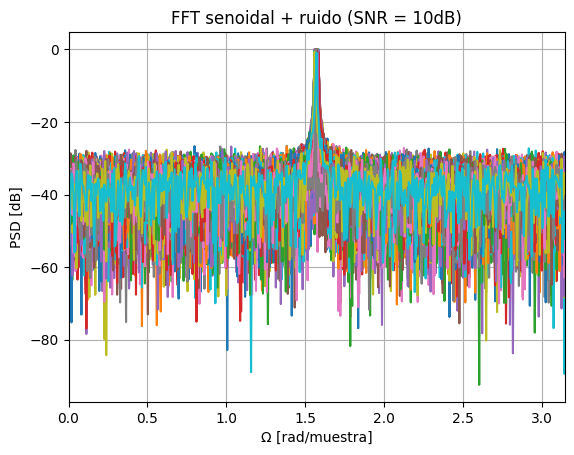

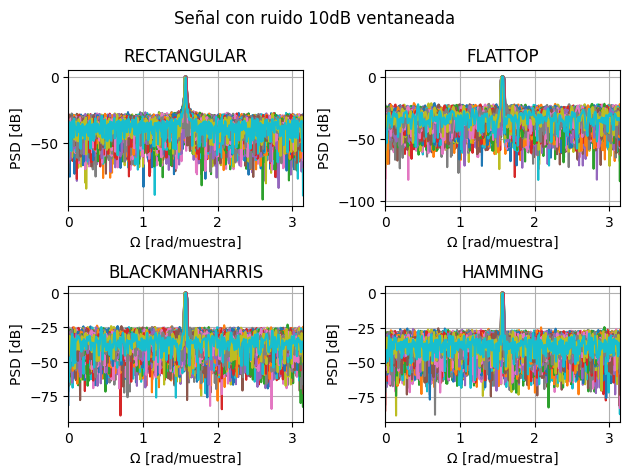

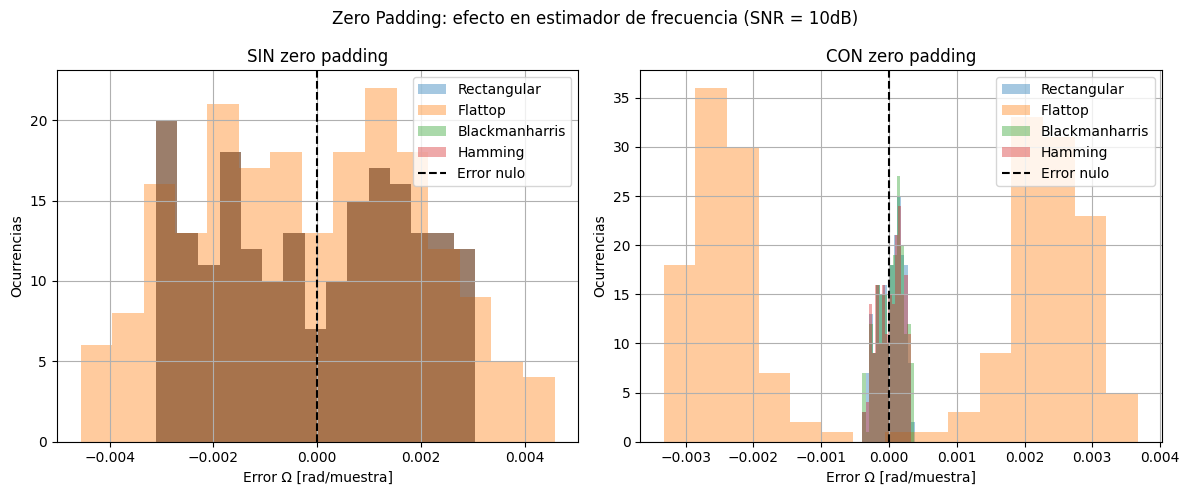

In [3]:
#%% SNR = 10dB
SNR = 10 # en dB
Ps = a0**2 / 2 #Potencia de 1 W
Pr = Ps / (10**(SNR/10))
desvio = np.sqrt(Pr)

na = np.random.normal(0, desvio, size = (R, N)) # ruido

# Señal
s_mat_10 = a0 * np.sin(f) + na

# Traspongo la señal para poder graficarla 
señal_t10 = np.transpose(s_mat_10)

plt.figure()
plt.title("Senoidal + ruido (SNR = 10dB)")
plt.plot(señal_t10)
plt.xlabel('n [muestras]')
plt.ylabel('Amplitud')
plt.grid()
plt.show()

# FFT
eps = 1e-12
S_mat_10 = np.fft.fft(s_mat_10, axis = 1) / N
S_mat_modulo10 = np.abs(S_mat_10)
S_mat_dB10 = 10 * np.log10(2*(S_mat_modulo10)**2 + eps)
S_mat_dB10 = np.transpose(S_mat_dB10)

plt.figure()
plt.title("FFT senoidal + ruido (SNR = 10dB)")
plt.plot(ff, S_mat_dB10)
plt.xlabel('Ω [rad/muestra]')
plt.ylabel('PSD [dB]') # Es la densidad espectral de potencia 
plt.xlim(0, fs/2)
plt.grid()
plt.show()

#%% Ventaneo SNR = 10dB 
# RECTANGULAR
s_vent_R10 = s_mat_10 * win_R

S_vent_R10 = np.fft.fft(s_vent_R10, axis=1) / N
S_vent_modulo_R10 = np.abs(S_vent_R10)
S_vent_R10_dB = 10 * np.log10(2*(S_vent_modulo_R10)**2 + eps)
S_vent_R10_dB = np.transpose(S_vent_R10_dB)

# FLATTOP
s_vent_F10 = s_mat_10 * win_F

S_vent_F10 = np.fft.fft(s_vent_F10, axis=1) / N
S_vent_modulo_F10 = np.abs(S_vent_F10)
S_vent_F10_dB = 10 * np.log10(2*(S_vent_modulo_F10)**2 + eps)
S_vent_F10_dB = np.transpose(S_vent_F10_dB)

# BLACKMANHARRIS
s_vent_B10 = s_mat_10 * win_B

S_vent_B10 = np.fft.fft(s_vent_B10, axis=1) / N
S_vent_modulo_B10 = np.abs(S_vent_B10)
S_vent_B10_dB = 10 * np.log10(2*(S_vent_modulo_B10)**2 + eps)
S_vent_B10_dB = np.transpose(S_vent_B10_dB)

# HAMMING
s_vent_H10 = s_mat_10 * win_H

S_vent_H10 = np.fft.fft(s_vent_H10, axis=1) / N
S_vent_modulo_H10 = np.abs(S_vent_H10)
S_vent_H10_dB = 10 * np.log10(2*(S_vent_modulo_H10)**2 + eps)
S_vent_H10_dB = np.transpose(S_vent_H10_dB)

# Graficos
plt.figure()
plt.suptitle("Señal con ruido 10dB ventaneada")

plt.subplot(2,2,1)
plt.title("RECTANGULAR")
plt.plot(ff, S_vent_R10_dB)
plt.xlabel('Ω [rad/muestra]')
plt.ylabel('PSD [dB]') # Es la densidad espectral de potencia 
plt.xlim(0, fs/2)
plt.grid()

plt.subplot(2,2,2)
plt.title("FLATTOP")
plt.plot(ff, S_vent_F10_dB)
plt.xlabel('Ω [rad/muestra]')
plt.ylabel('PSD [dB]') # Es la densidad espectral de potencia 
plt.xlim(0, fs/2)
plt.grid()

plt.subplot(2,2,3)
plt.title("BLACKMANHARRIS")
plt.plot(ff, S_vent_B10_dB)
plt.xlabel('Ω [rad/muestra]')
plt.ylabel('PSD [dB]') # Es la densidad espectral de potencia 
plt.xlim(0, fs/2)
plt.grid()

plt.subplot(2,2,4)
plt.title("HAMMING")
plt.plot(ff, S_vent_H10_dB)
plt.xlabel('Ω [rad/muestra]')
plt.ylabel('PSD [dB]') # Es la densidad espectral de potencia 
plt.xlim(0, fs/2)
plt.grid()

plt.tight_layout()
plt.show()

#%% Estimador de amplitud SNR = 10dB
# Ω0 = pi/2 corresponde al bin N/4 (Ω0/df = 250)
estimador_a_R10 = np.abs(S_vent_R10[:, N//4])*2
estimador_a_F10 = np.abs(S_vent_F10[:, N//4])*2
estimador_a_B10 = np.abs(S_vent_B10[:, N//4])*2
estimador_a_H10 = np.abs(S_vent_H10[:, N//4])*2

#%% SESGO Y VARIANZA SNR = 10dB
sesgo_amp_R10 = np.mean(estimador_a_R10) - a0 
sesgo_amp_F10 = np.mean(estimador_a_F10) - a0 
sesgo_amp_B10 = np.mean(estimador_a_B10) - a0 
sesgo_amp_H10 = np.mean(estimador_a_H10) - a0 

varianza_amp_R10 = np.var(estimador_a_R10)
varianza_amp_F10 = np.var(estimador_a_F10)
varianza_amp_B10 = np.var(estimador_a_B10)
varianza_amp_H10 = np.var(estimador_a_H10)

#%% Estimador de la frecuencia SNR = 10dB
# argmax devuelve el bin del pico --> multiplico por df para pasarlo a Ω [rad/muestra]
estimador_f_R10 = np.argmax(np.abs(S_vent_R10[:, :N//2]), axis = 1) * df
estimador_f_F10 = np.argmax(np.abs(S_vent_F10[:, :N//2]), axis = 1) * df
estimador_f_B10 = np.argmax(np.abs(S_vent_B10[:, :N//2]), axis = 1) * df
estimador_f_H10 = np.argmax(np.abs(S_vent_H10[:, :N//2]), axis = 1) * df

#%% SESGO Y VARIANZA SNR = 10dB
# Como Ω1 cambia en cada realización, se evalúa el error Ω1_estimada - Ω1
error_f_R10 = estimador_f_R10 - omega1.flatten()
error_f_F10 = estimador_f_F10 - omega1.flatten()
error_f_B10 = estimador_f_B10 - omega1.flatten()
error_f_H10 = estimador_f_H10 - omega1.flatten()

sesgo_frec_R10 = np.mean(error_f_R10)
sesgo_frec_F10 = np.mean(error_f_F10)
sesgo_frec_B10 = np.mean(error_f_B10)
sesgo_frec_H10 = np.mean(error_f_H10)

varianza_frec_R10 = np.var(error_f_R10)
varianza_frec_F10 = np.var(error_f_F10)
varianza_frec_B10 = np.var(error_f_B10)
varianza_frec_H10 = np.var(error_f_H10)

#%% Efecto del zero padding en el estimador de frecuencia (SNR = 10dB)
N_zp = 10 * N  # 10000 puntos
df_zp = fs / N_zp # nueva separación entre bins (10 veces más chica)

# Rectangular
zp_W_R10 = np.fft.fft(s_vent_R10, n = N_zp, axis = 1)
estimador_f_zp_R10 = np.argmax(np.abs(zp_W_R10[:, :N_zp//2]), axis = 1) * df_zp

# Flattop
zp_W_F10 = np.fft.fft(s_vent_F10, n = N_zp, axis = 1)
estimador_f_zp_F10 = np.argmax(np.abs(zp_W_F10[:, :N_zp//2]), axis = 1) * df_zp

# Blackmanharris
zp_W_B10 = np.fft.fft(s_vent_B10, n = N_zp, axis = 1)
estimador_f_zp_B10 = np.argmax(np.abs(zp_W_B10[:, :N_zp//2]), axis = 1) * df_zp

# Hamming
zp_W_H10 = np.fft.fft(s_vent_H10, n = N_zp, axis = 1)
estimador_f_zp_H10 = np.argmax(np.abs(zp_W_H10[:, :N_zp//2]), axis = 1) * df_zp

# Sesgo y varianza CON zero padding
error_f_zp_R10 = estimador_f_zp_R10 - omega1.flatten()
error_f_zp_F10 = estimador_f_zp_F10 - omega1.flatten()
error_f_zp_B10 = estimador_f_zp_B10 - omega1.flatten()
error_f_zp_H10 = estimador_f_zp_H10 - omega1.flatten()

sesgo_f_zp_R10 = np.mean(error_f_zp_R10)
sesgo_f_zp_F10 = np.mean(error_f_zp_F10)
sesgo_f_zp_B10 = np.mean(error_f_zp_B10)
sesgo_f_zp_H10 = np.mean(error_f_zp_H10)

var_f_zp_R10 = np.var(error_f_zp_R10)
var_f_zp_F10 = np.var(error_f_zp_F10)
var_f_zp_B10 = np.var(error_f_zp_B10)
var_f_zp_H10 = np.var(error_f_zp_H10)

#%% Histograma comparativo ZP vs sin ZP
plt.figure(figsize=(12, 5))
plt.suptitle("Zero Padding: efecto en estimador de frecuencia (SNR = 10dB)")

plt.subplot(1, 2, 1)
plt.title("SIN zero padding")
plt.hist(error_f_R10, label = 'Rectangular', alpha = 0.4, bins = 15)
plt.hist(error_f_F10, label = 'Flattop', alpha = 0.4, bins = 15)
plt.hist(error_f_B10, label = 'Blackmanharris', alpha = 0.4, bins = 15)
plt.hist(error_f_H10, label = 'Hamming', alpha = 0.4, bins = 15)
plt.axvline(0, color = 'k', linestyle = '--', label = 'Error nulo')
plt.xlabel('Error Ω [rad/muestra]')
plt.ylabel('Ocurrencias')
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.title("CON zero padding")
plt.hist(error_f_zp_R10, label = 'Rectangular', alpha = 0.4, bins = 15)
plt.hist(error_f_zp_F10, label = 'Flattop', alpha = 0.4, bins = 15)
plt.hist(error_f_zp_B10, label = 'Blackmanharris', alpha = 0.4, bins = 15)
plt.hist(error_f_zp_H10, label = 'Hamming', alpha = 0.4, bins = 15)
plt.axvline(0, color = 'k', linestyle = '--', label = 'Error nulo')
plt.xlabel('Error Ω [rad/muestra]')
plt.ylabel('Ocurrencias')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

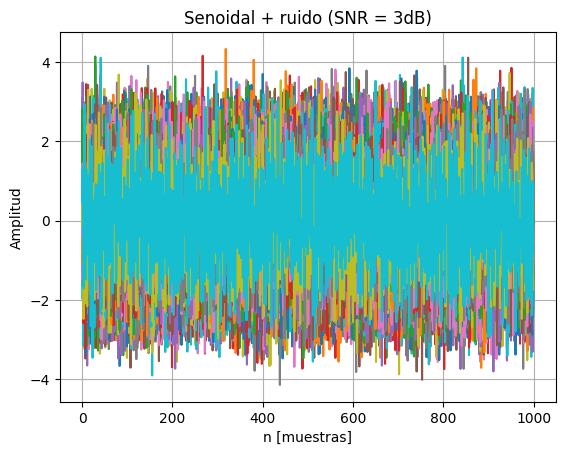

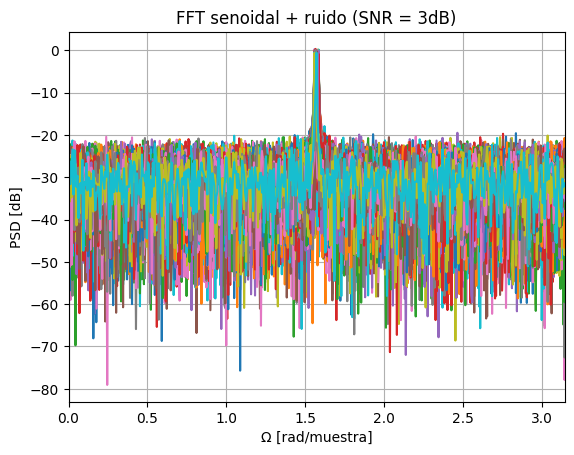

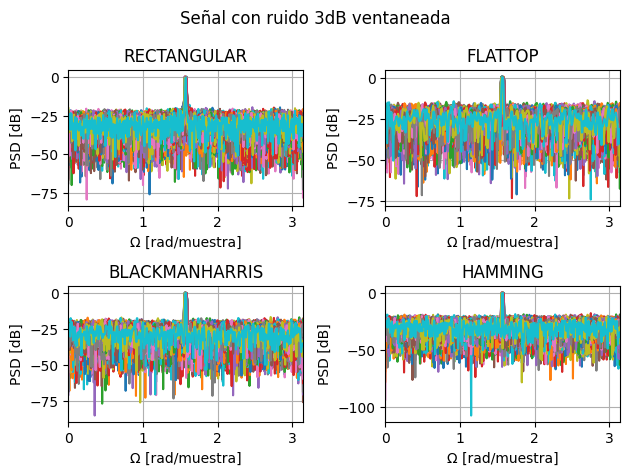

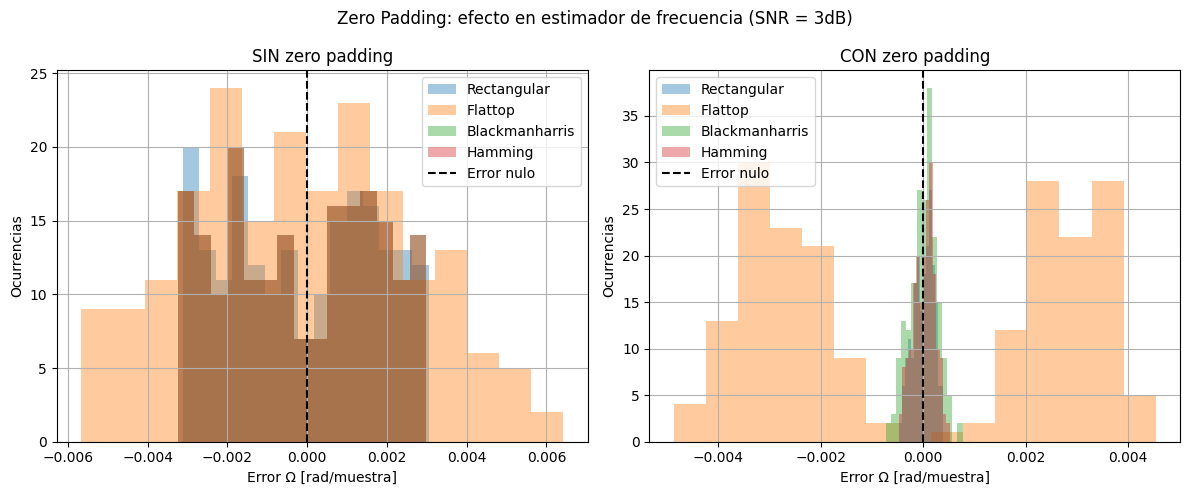

In [4]:
#%% SNR = 3dB
SNR = 3 # en dB
Ps = a0**2 / 2 #Potencia de 1 W
Pr = Ps / (10**(SNR/10))
desvio = np.sqrt(Pr)

na = np.random.normal(0, desvio, size = (R, N)) # ruido

# Señal
s_mat_3 = a0 * np.sin(f) + na

# Traspongo la señal para poder graficarla 
señal_t3 = np.transpose(s_mat_3)

plt.figure()
plt.title("Senoidal + ruido (SNR = 3dB)")
plt.plot(señal_t3)
plt.xlabel('n [muestras]')
plt.ylabel('Amplitud')
plt.grid()
plt.show()

# FFT
eps = 1e-12
S_mat_3 = np.fft.fft(s_mat_3, axis = 1) / N
S_mat_modulo3 = np.abs(S_mat_3)
S_mat_dB3 = 10 * np.log10(2*(S_mat_modulo3)**2 + eps)
S_mat_dB3 = np.transpose(S_mat_dB3)

plt.figure()
plt.title("FFT senoidal + ruido (SNR = 3dB)")
plt.plot(ff, S_mat_dB3)
plt.xlabel('Ω [rad/muestra]')
plt.ylabel('PSD [dB]') # Es la densidad espectral de potencia 
plt.xlim(0, fs/2)
plt.grid()
plt.show()

#%% Ventaneo SNR = 3dB 
# RECTANGULAR
s_vent_R3 = s_mat_3 * win_R

S_vent_R3 = np.fft.fft(s_vent_R3, axis=1) / N
S_vent_modulo_R3 = np.abs(S_vent_R3)
S_vent_R3_dB = 10 * np.log10(2*(S_vent_modulo_R3)**2 + eps)
S_vent_R3_dB = np.transpose(S_vent_R3_dB)

# FLATTOP
s_vent_F3 = s_mat_3 * win_F

S_vent_F3 = np.fft.fft(s_vent_F3, axis=1) / N
S_vent_modulo_F3 = np.abs(S_vent_F3)
S_vent_F3_dB = 10 * np.log10(2*(S_vent_modulo_F3)**2 + eps)
S_vent_F3_dB = np.transpose(S_vent_F3_dB)

# BLACKMANHARRIS
s_vent_B3 = s_mat_3 * win_B

S_vent_B3 = np.fft.fft(s_vent_B3, axis=1) / N
S_vent_modulo_B3 = np.abs(S_vent_B3)
S_vent_B3_dB = 10 * np.log10(2*(S_vent_modulo_B3)**2 + eps)
S_vent_B3_dB = np.transpose(S_vent_B3_dB)

# HAMMING
s_vent_H3 = s_mat_3 * win_H

S_vent_H3 = np.fft.fft(s_vent_H3, axis=1) / N
S_vent_modulo_H3 = np.abs(S_vent_H3)
S_vent_H3_dB = 10 * np.log10(2*(S_vent_modulo_H3)**2 + eps)
S_vent_H3_dB = np.transpose(S_vent_H3_dB)

# Graficos
plt.figure()
plt.suptitle("Señal con ruido 3dB ventaneada")

plt.subplot(2,2,1)
plt.title("RECTANGULAR")
plt.plot(ff, S_vent_R3_dB)
plt.xlabel('Ω [rad/muestra]')
plt.ylabel('PSD [dB]') # Es la densidad espectral de potencia 
plt.xlim(0, fs/2)
plt.grid()

plt.subplot(2,2,2)
plt.title("FLATTOP")
plt.plot(ff, S_vent_F3_dB)
plt.xlabel('Ω [rad/muestra]')
plt.ylabel('PSD [dB]') # Es la densidad espectral de potencia 
plt.xlim(0, fs/2)
plt.grid()

plt.subplot(2,2,3)
plt.title("BLACKMANHARRIS")
plt.plot(ff, S_vent_B3_dB)
plt.xlabel('Ω [rad/muestra]')
plt.ylabel('PSD [dB]') # Es la densidad espectral de potencia 
plt.xlim(0, fs/2)
plt.grid()

plt.subplot(2,2,4)
plt.title("HAMMING")
plt.plot(ff, S_vent_H3_dB)
plt.xlabel('Ω [rad/muestra]')
plt.ylabel('PSD [dB]') # Es la densidad espectral de potencia 
plt.xlim(0, fs/2)
plt.grid()

plt.tight_layout()
plt.show()

#%% Estimador de amplitud SNR = 3dB
# Ω0 = pi/2 corresponde al bin N/4 (Ω0/df = 250)
estimador_a_R3 = np.abs(S_vent_R3[:, N//4])*2
estimador_a_F3 = np.abs(S_vent_F3[:, N//4])*2
estimador_a_B3 = np.abs(S_vent_B3[:, N//4])*2
estimador_a_H3 = np.abs(S_vent_H3[:, N//4])*2

#%% SESGO Y VARIANZA SNR = 3dB
sesgo_amp_R3 = np.mean(estimador_a_R3) - a0 
sesgo_amp_F3 = np.mean(estimador_a_F3) - a0 
sesgo_amp_B3 = np.mean(estimador_a_B3) - a0 
sesgo_amp_H3 = np.mean(estimador_a_H3) - a0 

varianza_amp_R3 = np.var(estimador_a_R3)
varianza_amp_F3 = np.var(estimador_a_F3)
varianza_amp_B3 = np.var(estimador_a_B3)
varianza_amp_H3 = np.var(estimador_a_H3)

#%% Estimador de la frecuencia SNR = 3dB
# argmax devuelve el bin del pico --> multiplico por df para pasarlo a Ω [rad/muestra]
estimador_f_R3 = np.argmax(np.abs(S_vent_R3[:, :N//2]), axis = 1) * df
estimador_f_F3 = np.argmax(np.abs(S_vent_F3[:, :N//2]), axis = 1) * df
estimador_f_B3 = np.argmax(np.abs(S_vent_B3[:, :N//2]), axis = 1) * df
estimador_f_H3 = np.argmax(np.abs(S_vent_H3[:, :N//2]), axis = 1) * df

#%% SESGO Y VARIANZA SNR = 3dB
# Como Ω1 cambia en cada realización, se evalúa el error Ω1_estimada - Ω1
error_f_R3 = estimador_f_R3 - omega1.flatten()
error_f_F3 = estimador_f_F3 - omega1.flatten()
error_f_B3 = estimador_f_B3 - omega1.flatten()
error_f_H3 = estimador_f_H3 - omega1.flatten()

sesgo_frec_R3 = np.mean(error_f_R3)
sesgo_frec_F3 = np.mean(error_f_F3)
sesgo_frec_B3 = np.mean(error_f_B3)
sesgo_frec_H3 = np.mean(error_f_H3)

varianza_frec_R3 = np.var(error_f_R3)
varianza_frec_F3 = np.var(error_f_F3)
varianza_frec_B3 = np.var(error_f_B3)
varianza_frec_H3 = np.var(error_f_H3)

#%% Efecto del zero padding en el estimador de frecuencia (SNR = 3dB)
N_zp = 10 * N  # 10000 puntos
df_zp = fs / N_zp # nueva separación entre bins (10 veces más chica)

# Rectangular
zp_W_R3 = np.fft.fft(s_vent_R3, n = N_zp, axis = 1)
estimador_f_zp_R3 = np.argmax(np.abs(zp_W_R3[:, :N_zp//2]), axis = 1) * df_zp

# Flattop
zp_W_F3 = np.fft.fft(s_vent_F3, n = N_zp, axis = 1)
estimador_f_zp_F3 = np.argmax(np.abs(zp_W_F3[:, :N_zp//2]), axis = 1) * df_zp

# Blackmanharris
zp_W_B3 = np.fft.fft(s_vent_B3, n = N_zp, axis = 1)
estimador_f_zp_B3 = np.argmax(np.abs(zp_W_B3[:, :N_zp//2]), axis = 1) * df_zp

# Hamming
zp_W_H3 = np.fft.fft(s_vent_H3, n = N_zp, axis = 1)
estimador_f_zp_H3 = np.argmax(np.abs(zp_W_H3[:, :N_zp//2]), axis = 1) * df_zp

# Sesgo y varianza CON zero padding
error_f_zp_R3 = estimador_f_zp_R3 - omega1.flatten()
error_f_zp_F3 = estimador_f_zp_F3 - omega1.flatten()
error_f_zp_B3 = estimador_f_zp_B3 - omega1.flatten()
error_f_zp_H3 = estimador_f_zp_H3 - omega1.flatten()

sesgo_f_zp_R3 = np.mean(error_f_zp_R3)
sesgo_f_zp_F3 = np.mean(error_f_zp_F3)
sesgo_f_zp_B3 = np.mean(error_f_zp_B3)
sesgo_f_zp_H3 = np.mean(error_f_zp_H3)

var_f_zp_R3 = np.var(error_f_zp_R3)
var_f_zp_F3 = np.var(error_f_zp_F3)
var_f_zp_B3 = np.var(error_f_zp_B3)
var_f_zp_H3 = np.var(error_f_zp_H3)

#%% Histograma comparativo ZP vs sin ZP
plt.figure(figsize=(12, 5))
plt.suptitle("Zero Padding: efecto en estimador de frecuencia (SNR = 3dB)")

plt.subplot(1, 2, 1)
plt.title("SIN zero padding")
plt.hist(error_f_R3, label = 'Rectangular', alpha = 0.4, bins = 15)
plt.hist(error_f_F3, label = 'Flattop', alpha = 0.4, bins = 15)
plt.hist(error_f_B3, label = 'Blackmanharris', alpha = 0.4, bins = 15)
plt.hist(error_f_H3, label = 'Hamming', alpha = 0.4, bins = 15)
plt.axvline(0, color = 'k', linestyle = '--', label = 'Error nulo')
plt.xlabel('Error Ω [rad/muestra]')
plt.ylabel('Ocurrencias')
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.title("CON zero padding")
plt.hist(error_f_zp_R3, label = 'Rectangular', alpha = 0.4, bins = 15)
plt.hist(error_f_zp_F3, label = 'Flattop', alpha = 0.4, bins = 15)
plt.hist(error_f_zp_B3, label = 'Blackmanharris', alpha = 0.4, bins = 15)
plt.hist(error_f_zp_H3, label = 'Hamming', alpha = 0.4, bins = 15)
plt.axvline(0, color = 'k', linestyle = '--', label = 'Error nulo')
plt.xlabel('Error Ω [rad/muestra]')
plt.ylabel('Ocurrencias')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

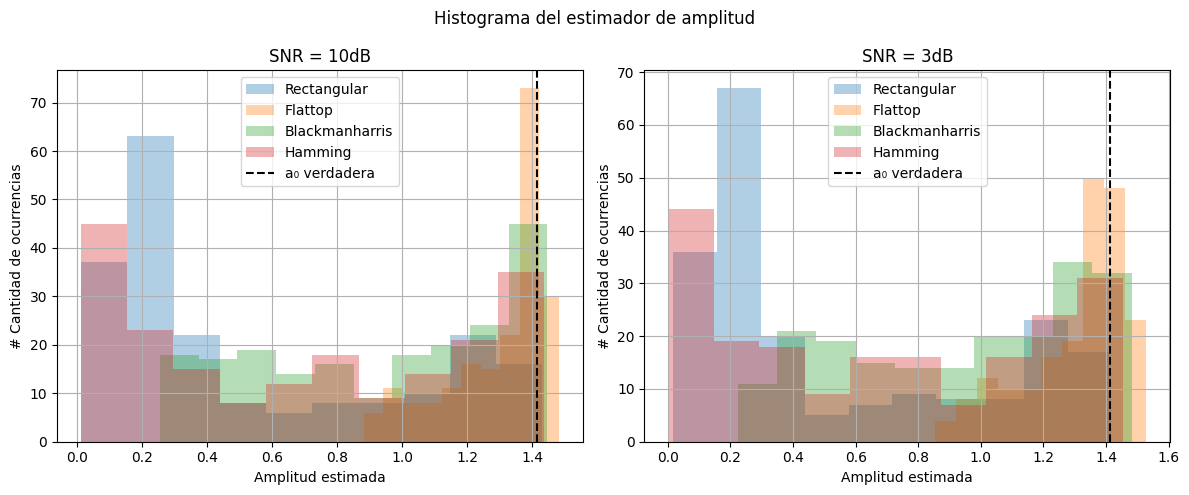

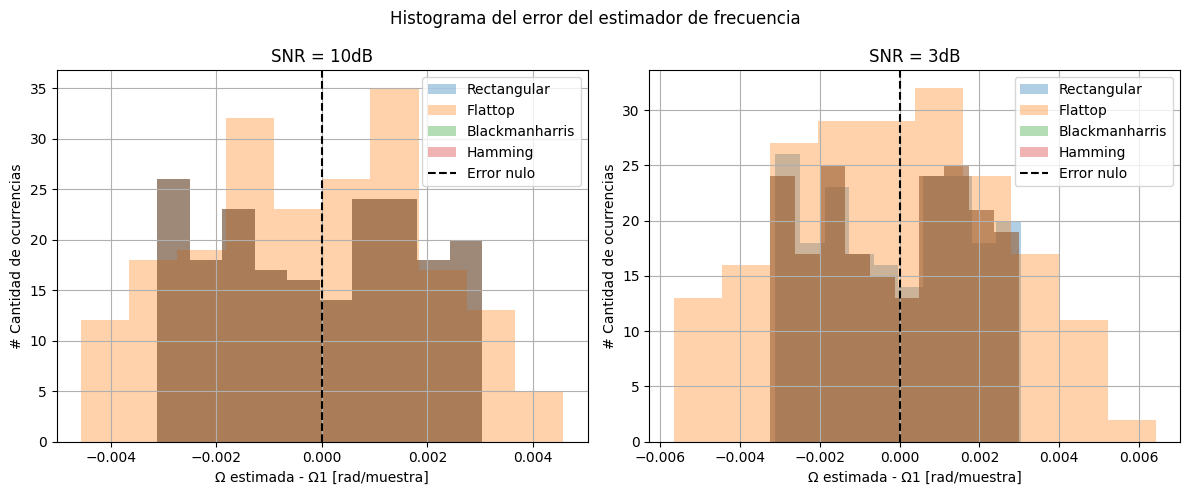

In [5]:
#%% Histogramas de los estimadores de amplitud 
trans = 0.35
bins = 10

# Histograma

plt.figure(figsize=(12, 5))
plt.suptitle("Histograma del estimador de amplitud")

plt.subplot(1,2,1)
plt.title("SNR = 10dB")
plt.hist(estimador_a_R10, label = 'Rectangular', alpha = trans, bins = bins)
plt.hist(estimador_a_F10, label = 'Flattop', alpha = trans, bins = bins)
plt.hist(estimador_a_B10, label = 'Blackmanharris', alpha = trans, bins = bins)
plt.hist(estimador_a_H10, label = 'Hamming', alpha = trans, bins = bins)
plt.axvline(a0, color = 'k', linestyle = '--', label = 'a₀ verdadera')
plt.xlabel('Amplitud estimada')
plt.ylabel('# Cantidad de ocurrencias')
plt.legend()
plt.grid()

plt.subplot(1,2,2)
plt.title("SNR = 3dB")
plt.hist(estimador_a_R3, label = 'Rectangular', alpha = trans, bins = bins)
plt.hist(estimador_a_F3, label = 'Flattop', alpha = trans, bins = bins)
plt.hist(estimador_a_B3, label = 'Blackmanharris', alpha = trans, bins = bins)
plt.hist(estimador_a_H3, label = 'Hamming', alpha = trans, bins = bins)
plt.axvline(a0, color = 'k', linestyle = '--', label = 'a₀ verdadera')
plt.xlabel('Amplitud estimada')
plt.ylabel('# Cantidad de ocurrencias')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

#%% Histogramas de los estimadores de frecuencia
plt.figure(figsize=(12, 5))
plt.suptitle("Histograma del error del estimador de frecuencia")

plt.subplot(1,2,1)
plt.title("SNR = 10dB") 
plt.hist(error_f_R10, label = 'Rectangular', alpha = trans, bins = bins)
plt.hist(error_f_F10, label = 'Flattop', alpha = trans, bins = bins)
plt.hist(error_f_B10, label = 'Blackmanharris', alpha = trans, bins = bins)
plt.hist(error_f_H10, label = 'Hamming', alpha = trans, bins = bins)
plt.axvline(0, color = 'k', linestyle = '--', label = 'Error nulo')
plt.xlabel('Ω estimada - Ω1 [rad/muestra]')
plt.ylabel('# Cantidad de ocurrencias')
plt.legend()
plt.grid()

plt.subplot(1,2,2)
plt.title("SNR = 3dB")
plt.hist(error_f_R3, label = 'Rectangular', alpha = trans, bins = bins)
plt.hist(error_f_F3, label = 'Flattop', alpha = trans, bins = bins)
plt.hist(error_f_B3, label = 'Blackmanharris', alpha = trans, bins = bins)
plt.hist(error_f_H3, label = 'Hamming', alpha = trans, bins = bins)
plt.axvline(0, color = 'k', linestyle = '--', label = 'Error nulo')
plt.xlabel('Ω estimada - Ω1 [rad/muestra]')
plt.ylabel('# Cantidad de ocurrencias')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

# <h3>CONCLUSIONES<h3>
El estimador de amplitud es muy dependiente de la ventana

El sesgo de amplitud lo domina la desintonía (scalloping), no el ruido: por eso casi no cambia entre 10 dB y 3 dB

La flattop tiene el menor sesgo y la menor varianza de amplitud (esta diseñada para medir amplitud). La rectangular es la peor: con fr = ±2 cae en un cero del sinc

El estimador de la frecuencia casi no depende de la ventana: el error queda acotado a medio bin (±π/N) y la varianza da ≈ Δf²/12

La flattop es la peor para frecuencia: su lóbulo principal es ancho y plano, entonces el ruido mueve facilmente el máximo

Zero padding --> baja la varianza porque estoy midiendo en mas puntos intermedios (Δf²/12 baja 100 veces con N_zp = 10N)

Tengo una mejor resolucion espectral ficticia pero efectiva a la hora de estimar la frecuencia. No sirve con la flattop: su cima es plana (con un ripple minimo), entonces el maximo queda corrido ±0.3 bins y lo termina de definir el ruido

na es un proceso gaussiano incorrelado, cuando promediamos eso tiende a cero

In [6]:
#%% IMPRESION DE TABLAS
print("\n" + "="*60)
print("ESTIMACIÓN DE AMPLITUD")
print("="*60)
print(f"{'Ventana':<16}{'sa (10dB)':>12}{'va (10dB)':>12}{'sa (3dB)':>12}{'va (3dB)':>12}")
print(f"{'Rectangular':<16}{sesgo_amp_R10:>12.4f}{varianza_amp_R10:>12.5f}{sesgo_amp_R3:>12.4f}{varianza_amp_R3:>12.5f}")
print(f"{'Flat-top':<16}{sesgo_amp_F10:>12.4f}{varianza_amp_F10:>12.5f}{sesgo_amp_F3:>12.4f}{varianza_amp_F3:>12.5f}")
print(f"{'Blackmanharris':<16}{sesgo_amp_B10:>12.4f}{varianza_amp_B10:>12.5f}{sesgo_amp_B3:>12.4f}{varianza_amp_B3:>12.5f}")
print(f"{'Hamming':<16}{sesgo_amp_H10:>12.4f}{varianza_amp_H10:>12.5f}{sesgo_amp_H3:>12.4f}{varianza_amp_H3:>12.5f}")

print("\n" + "="*60)
print("ESTIMACIÓN DE FRECUENCIA [rad/muestra]")
print("="*60)
print(f"{'Ventana':<16}{'sf (10dB)':>12}{'vf (10dB)':>12}{'sf (3dB)':>12}{'vf (3dB)':>12}")
print(f"{'Rectangular':<16}{sesgo_frec_R10:>12.2e}{varianza_frec_R10:>12.2e}{sesgo_frec_R3:>12.2e}{varianza_frec_R3:>12.2e}")
print(f"{'Flat-top':<16}{sesgo_frec_F10:>12.2e}{varianza_frec_F10:>12.2e}{sesgo_frec_F3:>12.2e}{varianza_frec_F3:>12.2e}")
print(f"{'Blackmanharris':<16}{sesgo_frec_B10:>12.2e}{varianza_frec_B10:>12.2e}{sesgo_frec_B3:>12.2e}{varianza_frec_B3:>12.2e}")
print(f"{'Hamming':<16}{sesgo_frec_H10:>12.2e}{varianza_frec_H10:>12.2e}{sesgo_frec_H3:>12.2e}{varianza_frec_H3:>12.2e}")

print("\n" + "="*60)
print("ESTIMACIÓN DE FRECUENCIA CON ZERO PADDING [rad/muestra]")
print("="*60)
print(f"{'Ventana':<16}{'sf (10dB)':>12}{'vf (10dB)':>12}{'sf (3dB)':>12}{'vf (3dB)':>12}")
print(f"{'Rectangular':<16}{sesgo_f_zp_R10:>12.2e}{var_f_zp_R10:>12.2e}{sesgo_f_zp_R3:>12.2e}{var_f_zp_R3:>12.2e}")
print(f"{'Flat-top':<16}{sesgo_f_zp_F10:>12.2e}{var_f_zp_F10:>12.2e}{sesgo_f_zp_F3:>12.2e}{var_f_zp_F3:>12.2e}")
print(f"{'Blackmanharris':<16}{sesgo_f_zp_B10:>12.2e}{var_f_zp_B10:>12.2e}{sesgo_f_zp_B3:>12.2e}{var_f_zp_B3:>12.2e}")
print(f"{'Hamming':<16}{sesgo_f_zp_H10:>12.2e}{var_f_zp_H10:>12.2e}{sesgo_f_zp_H3:>12.2e}{var_f_zp_H3:>12.2e}")


ESTIMACIÓN DE AMPLITUD
Ventana            sa (10dB)   va (10dB)    sa (3dB)    va (3dB)
Rectangular          -0.8779     0.20435     -0.8774     0.20497
Flat-top             -0.1172     0.02342     -0.1095     0.02502
Blackmanharris       -0.4740     0.14025     -0.4686     0.13814
Hamming              -0.7324     0.24944     -0.7247     0.24277

ESTIMACIÓN DE FRECUENCIA [rad/muestra]
Ventana            sf (10dB)   vf (10dB)    sf (3dB)    vf (3dB)
Rectangular        -1.05e-04    3.44e-06   -1.05e-04    3.44e-06
Flat-top           -1.99e-04    4.61e-06   -2.31e-04    7.46e-06
Blackmanharris     -1.05e-04    3.44e-06   -1.37e-04    3.44e-06
Hamming            -1.05e-04    3.44e-06   -1.37e-04    3.44e-06

ESTIMACIÓN DE FRECUENCIA CON ZERO PADDING [rad/muestra]
Ventana            sf (10dB)   vf (10dB)    sf (3dB)    vf (3dB)
Rectangular         2.04e-05    3.32e-08    1.10e-05    3.83e-08
Flat-top            9.58e-05    6.03e-06   -6.13e-05    8.55e-06
Blackmanharris      2.98e-05    3.